In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
import pickle 
from keras.utils import np_utils
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed, Input, BatchNormalization, \
    concatenate, Activation, dot, Lambda, Reshape
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import backend as K
import tensorflow as tf
import pandas as pd
from sklearn.utils import shuffle
from sklearn.metrics import mean_squared_error, mean_absolute_error

from sklearn.pipeline import Pipeline

from sklearn import preprocessing

import statsmodels.api as sm
import math

import glob
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

In [2]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 13468350962373759635
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 6252920832
locality {
  bus_id: 1
  links {
  }
}
incarnation: 7017128868230492947
physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 2080 Super with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5"
]


In [3]:
import os
import random
import numpy as np
import tensorflow as tf

SEED = 41 

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
import numpy as np
import os
from sklearn.preprocessing import StandardScaler

train_data_path = r'D:\train'
test_data_path = r'D:\test'

def read_npy_files(directory_path):
    file_data = {}
    for file_name in os.listdir(directory_path):
        if file_name.endswith('.npy'):
            file_path = os.path.join(directory_path, file_name)
            file_data[file_name] = np.load(file_path)
    return file_data

train_data = read_npy_files(train_data_path)
#test_data = read_npy_files(test_data_path)
test_data_nopad = read_npy_files(test_data_path)

max_frames = max([data.shape[0] for data in train_data.values()] + [data.shape[0] for data in test_data_nopad.values()])

def pad_npy_files(data_dict, max_frames):
    padded_data = {}
    for file_name, data in data_dict.items():
        num_frames, num_joints = data.shape
        if num_frames < max_frames:
            padded_array = np.zeros((max_frames, num_joints))
            padded_array[:num_frames, :] = data
            padded_data[file_name] = padded_array
        else:
            padded_data[file_name] = data
    return padded_data

train_data_padded = pad_npy_files(train_data, max_frames)
test_data_padded = pad_npy_files(test_data_nopad, max_frames)

def extract_labels(file_names):
    labels = []
    for file_name in file_names:
        class_name = file_name.split('_', 2)[-1].rsplit('_', 1)[0]    
        print(class_name)
        labels.append(class_name)
    return labels

train_labels = extract_labels(train_data_padded.keys())
test_labels = extract_labels(test_data_padded.keys())

train_data_list = list(train_data_padded.values())
test_data_list = list(test_data_padded.values())

for i, data in enumerate(train_data_list):
    print(f"Train data {i} shape: {data.shape}")
for i, data in enumerate(test_data_list):
    print(f"Test data {i} shape: {data.shape}")

all_data = train_data_list + test_data_list 
all_labels = train_labels + test_labels

X_data = np.array(all_data)  

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()
y_data = label_encoder.fit_transform(all_labels)
y_data = to_categorical(y_data, num_classes=17)  

num_train = len(train_data_list)
X_train_prim, X_test_prim = X_data[:num_train], X_data[num_train:]
y_train_prim, y_test_prim = y_data[:num_train], y_data[num_train:]

print("X_train_prim shape:", X_train_prim.shape)  
print("y_train_prim shape:", y_train_prim.shape)
print("X_test prim shape:", X_test_prim.shape)
print("y_test prim shape:", y_test_prim.shape)

scaler = StandardScaler()

X_train_prim = scaler.fit_transform(X_train_prim.reshape(X_train_prim.shape[0], X_train_prim.shape[1] * X_train_prim.shape[2])).reshape(X_train_prim.shape[0], X_train_prim.shape[1], X_train_prim.shape[2])
X_test_prim = scaler.transform(X_test_prim.reshape(X_test_prim.shape[0], X_test_prim.shape[1] * X_test_prim.shape[2])).reshape(X_test_prim.shape[0], X_test_prim.shape[1], X_test_prim.shape[2])


Kneeling_Upright
Kneeling_Upright
Kneeling_Upright
Kneeling_Upright
Kneeling_Upright
Kneeling_Upright
Kneeling_Upright
Kneeling_Upright
Kneeling_Upright
Kneeling_Upright
Kneeling_Upright
Kneeling_Upright
Kneeling_Upright
Kneeling_Upright
Kneeling_Upright
Kneeling_Upright
Kneeling_Upright
Kneeling_Upright
Kneeling_Upright
Kneeling_Upright
Kneeling_Upright
Standing_Ipose
Standing_Ipose
Standing_Ipose
Standing_Ipose
Standing_Ipose
Standing_Ipose
Standing_Ipose
Standing_Ipose
Standing_Ipose
Standing_Ipose
Standing_Ipose
Standing_Ipose
Standing_Ipose
Standing_Ipose
Standing_Ipose
Standing_Ipose
Standing_Ipose
Standing_Ipose
Standing_Ipose
Standing_Ipose
Standing_Ipose
Standing_Ipose
Standing_Ipose
Standing_Ipose
Standing_Ipose
Upright
Upright
Upright
Upright
Upright
Upright
Upright
Upright
Upright
Upright
Upright
Upright
Upright
Upright
Upright
Upright
Upright
Upright
Upright
Upright
Upright
Upright
Upright
Upright
Upright
Upright
Upright
ForwardBending
ForwardBending
ForwardBending
Forward

In [5]:
import numpy as np
import os
from sklearn.preprocessing import StandardScaler

train_data_path = r'D:\train'
test_data_path = r'D:\test'

def read_npy_files(directory_path):
    file_data = {}
    for file_name in os.listdir(directory_path):
        if file_name.endswith('.npy'):
            file_path = os.path.join(directory_path, file_name)
            data = np.load(file_path)
            print(f"Read file: {file_name} with shape: {data.shape}")
            file_data[file_name] = data
    return file_data

train_data = read_npy_files(train_data_path)
test_data = read_npy_files(test_data_path)

max_frames = max([data.shape[0] for data in train_data.values()] + [data.shape[0] for data in test_data.values()])
print(f"Max frames: {max_frames}")

def pad_npy_files(data_dict, max_frames):
    padded_data = {}
    for file_name, data in data_dict.items():
        num_frames, num_joints = data.shape
        print(f"Padding file: {file_name}, original shape: {data.shape}")
        if num_frames < max_frames:
            padded_array = np.zeros((max_frames, num_joints))
            padded_array[:num_frames, :] = data
            padded_data[file_name] = padded_array
            print(f"Padded file: {file_name} to shape: {padded_array.shape}")
        else:
            padded_data[file_name] = data
    return padded_data

train_data_padded = pad_npy_files(train_data, max_frames)
test_data_padded = pad_npy_files(test_data, max_frames)

def extract_labels(file_names):
    labels = []
    for file_name in file_names:
        class_name = file_name.split('_')[1]  # Extract class
        print(f"Extracted label: {class_name} from file: {file_name}")
        labels.append(class_name)
    return labels

train_labels = extract_labels(train_data_padded.keys())
test_labels = extract_labels(test_data_padded.keys())

train_data_list = list(train_data_padded.values())
test_data_list = list(test_data_padded.values())

print("Train data shapes:")
for i, (file_name, data) in enumerate(train_data_padded.items()):  
    print(f"Train file {i} ({file_name}): original shape {data.shape}")
    data = data.reshape((1, 29074, 81))
    print(f"Train file {i} ({file_name}): reshaped to {data.shape}")

print("Test data shapes:")
for i, (file_name, data) in enumerate(test_data_padded.items()):  
    print(f"Test file {i} ({file_name}): original shape {data.shape}")
    data = data.reshape((1, 29074, 81))
    print(f"Test file {i} ({file_name}): reshaped to {data.shape}")

all_data = train_data_list + test_data_list
all_labels = train_labels + test_labels

print("all data", len(all_data))

print("All data shapes before stacking:")
for i, data in enumerate(all_data):
    print(f"Data {i}: shape {data.shape}")

X_data = np.array(all_data)  # Stack along a new axis
print(f"X_data shape after stacking: {X_data.shape}")

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()
y_data = label_encoder.fit_transform(all_labels)
y_data = to_categorical(y_data, num_classes=31) 

num_train = len(train_data_list)
X_train_actions, X_test_actions = X_data[:num_train], X_data[num_train:]
y_train_actions, y_test_actions = y_data[:num_train], y_data[num_train:]

print("X_train_actions shape:", X_train_actions.shape)
print("y_train_actions shape:", y_train_actions.shape)
print("X_test_actions shape:", X_test_actions.shape)
print("y_test_actions shape:", y_test_actions.shape)

scaler = StandardScaler()

try:
    X_train_actions = scaler.fit_transform(X_train_actions.reshape(X_train_actions.shape[0], X_train_actions.shape[1] * X_train_actions.shape[2])).reshape(X_train_actions.shape[0], X_train_actions.shape[1], X_train_actions.shape[2])
    X_test_actions = scaler.transform(X_test_actions.reshape(X_test_actions.shape[0], X_test_actions.shape[1] * X_test_actions.shape[2])).reshape(X_test_actions.shape[0], X_test_actions.shape[1], X_test_actions.shape[2])
    print("Standardization completed successfully.")
except Exception as e:
    print(f"Error during standardization: {e}")


Read file: train_WrappingTV_TVPS02P07R04.npy with shape: (3439, 81)
Read file: train_BeamPreparation_SWPBS01G01R01.npy with shape: (8581, 81)
Read file: train_BeamPreparation_SWPBS01G01R02.npy with shape: (1011, 81)
Read file: train_BeamPreparation_SWPBS01G01R03.npy with shape: (5137, 81)
Read file: train_BeamPreparation_SWPBS01G02R01.npy with shape: (6783, 81)
Read file: train_BeamPreparation_SWPBS01G02R02.npy with shape: (3729, 81)
Read file: train_BeamPreparation_SWPBS01G03R01.npy with shape: (1611, 81)
Read file: train_BeamPreparation_SWPBS01G03R02.npy with shape: (3897, 81)
Read file: train_BeamPreparation_SWPBS01G03R03.npy with shape: (11524, 81)
Read file: train_BeamPreparation_SWPBS01G03R04.npy with shape: (5980, 81)
Read file: train_Blocking_GBBSS01G01R01.npy with shape: (1015, 81)
Read file: train_Blocking_GBBSS01G01R02.npy with shape: (451, 81)
Read file: train_Blocking_GBBSS01G01R03.npy with shape: (2524, 81)
Read file: train_Blocking_GBBSS01G01R04.npy with shape: (919, 81)

In [6]:
import numpy as np
import os

train_load_path = r"D:\Activities"
test_load_path = r"D:\Activities"

X_train_act = np.load(os.path.join(train_load_path, "X_train.npy"))
y_train_act = np.load(os.path.join(train_load_path, "y_train.npy"))
print(f"Train data loaded: X_train_act shape = {X_train_act.shape}, y_train_act shape = {y_train_act.shape}")

X_test_act = np.load(os.path.join(test_load_path, "X_test.npy"))
y_test_act = np.load(os.path.join(test_load_path, "y_test.npy"))
print(f"Test data loaded: X_test_act shape = {X_test_act.shape}, y_test_act shape = {y_test_act.shape}")

Train data loaded: X_train_act shape = (302, 9477, 81), y_train_act shape = (302, 6)
Test data loaded: X_test_act shape = (67, 9825, 81), y_test_act shape = (67, 6)


In [7]:
X_train_actions=X_train_actions[:,::3,:]
print("Xtrain shape", X_train_actions.shape)

X_train_act = X_train_act[:, ::3, :]  
print("Xtrain shape", X_train_act.shape)

Xtrain shape (688, 9692, 81)
Xtrain shape (302, 3159, 81)


In [8]:
X_train_actions = X_train_actions[:, ::3, :] 
print("Xtrain shape", X_train_actions.shape)

Xtrain shape (688, 3231, 81)


In [9]:
from sklearn.model_selection import train_test_split

X_train_prim, X_val_prim, y_train_prim, y_val_prim = train_test_split(X_train_prim, y_train_prim, test_size=0.2, random_state=41)
X_train_actions, X_val_actions, y_train_actions, y_val_actions = train_test_split(X_train_actions, y_train_actions, test_size=0.2, random_state=41)
X_train_act, X_val_act, y_train_act, y_val_act = train_test_split(X_train_act, y_train_act, test_size=0.2, random_state=41)

In [10]:
print(X_train_prim.shape, y_train_prim.shape)
print(X_train_actions.shape, y_train_actions.shape)
print(X_train_act.shape, y_train_act.shape)

(538, 1567, 81) (538, 17)
(550, 3231, 81) (550, 31)
(241, 3159, 81) (241, 6)


In [11]:
import numpy as np
from sklearn.utils import resample

def equalize_sample_sizes_with_noise(task_data, task_labels, target_size):
    
    num_samples = task_data.shape[0]
    if num_samples >= target_size:
        return task_data, task_labels  

    samples_needed = target_size - num_samples

    additional_data = resample(task_data, n_samples=samples_needed, replace=True, random_state=41)
    additional_labels = resample(task_labels, n_samples=samples_needed, replace=True, random_state=41)

    new_task_data = np.concatenate([task_data, additional_data], axis=0)
    new_task_labels = np.concatenate([task_labels, additional_labels], axis=0)

    return new_task_data, new_task_labels

X_train_prim, y_train_prim = equalize_sample_sizes_with_noise(X_train_prim, y_train_prim, target_size=550)
X_train_actions, y_train_actions = equalize_sample_sizes_with_noise(X_train_actions, y_train_actions, target_size=550)
X_train_act, y_train_act = equalize_sample_sizes_with_noise(X_train_act, y_train_act, target_size=550)

print(f"Task 1: {X_train_prim.shape}, {y_train_prim.shape}")
print(f"Task 2: {X_train_actions.shape}, {y_train_actions.shape}")
print(f"Task 3: {X_train_act.shape}, {y_train_act.shape}")

Task 1: (550, 1567, 81), (550, 17)
Task 2: (550, 3231, 81), (550, 31)
Task 3: (550, 3159, 81), (550, 6)


In [12]:
print(X_train_prim.shape, y_train_prim.shape)
print(X_train_actions.shape, y_train_actions.shape)
print(X_train_act.shape, y_train_act.shape)

(550, 1567, 81) (550, 17)
(550, 3231, 81) (550, 31)
(550, 3159, 81) (550, 6)


In [13]:
def custom_loss(y_true1, y_pred1, y_true2, y_pred2, y_true3, y_pred3,
                w1, w2, w3, a1, a2, prev_loss1, prev_loss2):
    
    #task-specific losses
    loss_task1 = None
    loss_task2 = None
    loss_task3 = None

    if y_true1 is not None and y_pred1 is not None:
        loss_task1 = tf.keras.losses.categorical_crossentropy(y_true1, y_pred1)

    if y_true2 is not None and y_pred2 is not None:
        loss_task2 = tf.keras.losses.categorical_crossentropy(y_true2, y_pred2)

    if y_true3 is not None and y_pred3 is not None:
        loss_task3 = tf.keras.losses.categorical_crossentropy(y_true3, y_pred3)

    scaling_factor = 1e-4  

    total_loss = scaling_factor * (a1 * prev_loss1 + a2 * prev_loss2)

    # task-specific losses (weighted by w1, w2, w3)
    if loss_task1 is not None:
        total_loss += w1 * loss_task1
    if loss_task2 is not None:
        total_loss += w2 * loss_task2
    if loss_task3 is not None:
        total_loss += w3 * loss_task3

    regularization_loss = 1e-4 * (tf.square(a1) + tf.square(a2) + tf.square(w1) + tf.square(w2) + tf.square(w3))
    total_loss += regularization_loss

    prev_loss2.assign(prev_loss1)
    prev_loss1.assign(tf.reduce_mean(total_loss))

    return total_loss

In [14]:
class KalmanUpdateCallback(tf.keras.callbacks.Callback):
    def __init__(self, w1, w2, w3, a1, a2, error_estimate_w1, error_estimate_w2, error_estimate_w3, error_estimate_a1, error_estimate_a2):
        self.w1 = w1
        self.w2 = w2
        self.w3 = w3
        self.a1 = a1
        self.a2 = a2
        self.error_estimate_w1 = error_estimate_w1
        self.error_estimate_w2 = error_estimate_w2
        self.error_estimate_w3 = error_estimate_w3
        self.error_estimate_a1 = error_estimate_a1
        self.error_estimate_a2 = error_estimate_a2
        self.w1_uncertainty = 1.0
        self.w2_uncertainty = 1.0
        self.w3_uncertainty = 1.0
        self.a1_uncertainty = 1.0
        self.a2_uncertainty = 1.0

    def kalman_update(self, estimate, uncertainty, measurement, error_estimate):
        kalman_gain = uncertainty / (uncertainty + error_estimate)
        updated_estimate = estimate + kalman_gain * (measurement - estimate)
        updated_uncertainty = (1 - kalman_gain) * uncertainty
        return updated_estimate, updated_uncertainty

    def on_batch_end(self, batch, logs=None):
        task_losses = [
            logs.get('output_task1_loss', 0.0),
            logs.get('output_task2_loss', 0.0),
            logs.get('output_task3_loss', 0.0)
        ]
        mean_task_loss = sum(task_losses) / len(task_losses) 

        for i, (weight, loss, error_estimate) in enumerate(
            zip([self.w1, self.w2, self.w3], task_losses, [self.error_estimate_w1, self.error_estimate_w2, self.error_estimate_w3])
        ):
            moving_avg_loss = 0.9 * logs.get(f'prev_loss_task{i+1}', 0.0) + 0.1 * loss
            updated_weight, updated_uncertainty = self.kalman_update(
                estimate=weight.numpy(),
                uncertainty=getattr(self, f"w{i+1}_uncertainty"),
                measurement=moving_avg_loss,
                error_estimate=error_estimate
            )
            weight.assign(updated_weight)
            setattr(self, f"w{i+1}_uncertainty", updated_uncertainty)

        for i, coeff in enumerate([self.a1, self.a2], start=1):
            updated_coeff, updated_uncertainty = self.kalman_update(
                estimate=coeff.numpy(),
                uncertainty=getattr(self, f"a{i}_uncertainty"),
                measurement=mean_task_loss,
                error_estimate=getattr(self, f"error_estimate_a{i}")
            )
            coeff.assign(updated_coeff)
            setattr(self, f"a{i}_uncertainty", updated_uncertainty)

w1 = tf.Variable(1.0, trainable=True)
w2 = tf.Variable(1.0, trainable=True)
w3 = tf.Variable(1.0, trainable=True)
a1 = tf.Variable(0.5, trainable=True)
a2 = tf.Variable(0.3, trainable=True)
prev_loss1 = tf.Variable(0.0, trainable=False)
prev_loss2 = tf.Variable(0.0, trainable=False)

error_estimate_w1 = 1.0
error_estimate_w2 = 3.0
error_estimate_w3 = 1.0
error_estimate_a1 = 1.0
error_estimate_a2 = 1.0

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, ReLU, Dropout, Dense, Multiply, GlobalMaxPooling1D, MaxPooling1D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.optimizers import Adam

# Task-Specific Input Layers
input_task1 = Input(shape=(None, 81), name='input_task1')  
input_task2 = Input(shape=(None, 81), name='input_task2')
input_task3 = Input(shape=(None, 81), name='input_task3')

# Task-Specific Feature Extraction
def task_specific_cnn_block(input_layer, name_prefix):
    x = Conv1D(64, kernel_size=3, activation='relu', name=f'{name_prefix}_input_cnn')(input_layer)
    x = BatchNormalization(name=f'{name_prefix}_batch_norm')(x)
    x = MaxPooling1D(pool_size=2, name=f'{name_prefix}_max_pool')(x)
    return x

task1_features = task_specific_cnn_block(input_task1, 'task1')
task2_features = task_specific_cnn_block(input_task2, 'task2')
task3_features = task_specific_cnn_block(input_task3, 'task3')

# Shared CNN Layer 
def shared_cnn_block(features, name_prefix):
    x = Conv1D(128, kernel_size=3, activation='relu', name=f'{name_prefix}_shared_cnn')(features)
    x = BatchNormalization(name=f'{name_prefix}_shared_batch_norm')(x)
    x = MaxPooling1D(pool_size=2, name=f'{name_prefix}_shared_max_pool')(x)
    return x

shared_features1 = shared_cnn_block(task1_features, 'task1')
shared_features2 = shared_cnn_block(task2_features, 'task2')
shared_features3 = shared_cnn_block(task3_features, 'task3')

# Shared CNN Layer (Before Attention)
def additional_shared_cnn_block(features, name_prefix):
    x = Conv1D(128, kernel_size=3, activation='relu', name=f'{name_prefix}_additional_shared_cnn')(features)
    x = BatchNormalization(name=f'{name_prefix}_additional_shared_batch_norm')(x)
    x = MaxPooling1D(pool_size=2, name=f'{name_prefix}_additional_shared_max_pool')(x)
    return x

shared_features1 = additional_shared_cnn_block(shared_features1, 'task1')
shared_features2 = additional_shared_cnn_block(shared_features2, 'task2')
shared_features3 = additional_shared_cnn_block(shared_features3, 'task3')

#this is added here to see if and how task 3 will be affected
# Task 3-Specific CNN Block
def task3_specific_cnn_block(features, name_prefix):
    x = Conv1D(64, kernel_size=3, activation='relu', name=f'{name_prefix}_task3_specific_cnn')(features)
    x = BatchNormalization(name=f'{name_prefix}_task3_specific_batch_norm')(x)
    x = MaxPooling1D(pool_size=2, name=f'{name_prefix}_task3_specific_max_pool')(x)
    return x

# Apply Task-Specific CNN Block for Task 3
task1_specific_features = task3_specific_cnn_block(shared_features1, 'task1')
task3_specific_features = task3_specific_cnn_block(shared_features3, 'task3')

def attention_block(features, name):
    attention = Dense(1, activation='tanh', name=f'{name}_attention_dense')(features)
    attention = tf.nn.softmax(attention, axis=1, name=f'{name}_attention_softmax')
    attended_features = Multiply(name=f'{name}_attended')([features, attention])
    return attended_features

attended_features1 = attention_block(task1_specific_features, 'task1')
attended_features2 = attention_block(shared_features2, 'task2')
attended_features3 = attention_block(task3_specific_features, 'task3')

# Extra Shared CNN Layer (Post-Attention)
def shared_post_cnn_block(features, name_prefix):
    x = Conv1D(128, kernel_size=3, activation='relu', name=f'{name_prefix}_post_shared_cnn')(features)
    x = BatchNormalization(name=f'{name_prefix}_post_shared_batch_norm')(x)
    x = MaxPooling1D(pool_size=2, name=f'{name_prefix}_post_shared_max_pool')(x)
    return x

shared_post1 = shared_post_cnn_block(attended_features1, 'task1')
shared_post2 = shared_post_cnn_block(attended_features2, 'task2')
shared_post3 = shared_post_cnn_block(attended_features3, 'task3')

global_pool = GlobalMaxPooling1D()

output_task1 = Dense(17, activation='softmax', name='output_task1')(global_pool(shared_post1))
output_task2 = Dense(31, activation='softmax', name='output_task2')(global_pool(shared_post2))
output_task3 = Dense(6, activation='softmax', name='output_task3')(global_pool(shared_post3))

model = Model(inputs=[input_task1, input_task2, input_task3],
              outputs=[output_task1, output_task2, output_task3])

model.compile(optimizer='adam',
              loss={
                  'output_task1': lambda y_true, y_pred: custom_loss(
                      y_true, y_pred, None, None, None, None, w1, w2, w3, a1, a2, prev_loss1, prev_loss2),
                  'output_task2': lambda y_true, y_pred: custom_loss(
                      None, None, y_true, y_pred, None, None, w1, w2, w3, a1, a2, prev_loss1, prev_loss2),
                  'output_task3': lambda y_true, y_pred: custom_loss(
                      None, None, None, None, y_true, y_pred, w1, w2, w3, a1, a2, prev_loss1, prev_loss2)
              },
              metrics=['accuracy'])

model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_task1 (InputLayer)        [(None, None, 81)]   0                                            
__________________________________________________________________________________________________
input_task3 (InputLayer)        [(None, None, 81)]   0                                            
__________________________________________________________________________________________________
task1_input_cnn (Conv1D)        (None, None, 64)     15616       input_task1[0][0]                
__________________________________________________________________________________________________
task3_input_cnn (Conv1D)        (None, None, 64)     15616       input_task3[0][0]                
______________________________________________________________________________________________

Epoch 1/6000
9/9 [==============================] - 10s 237ms/step - loss: 4.5068 - output_task1_loss: 1.3913 - output_task2_loss: 2.3348 - output_task3_loss: 0.7807 - output_task1_accuracy: 0.1891 - output_task2_accuracy: 0.2600 - output_task3_accuracy: 0.5455
Epoch 2/6000
9/9 [==============================] - 3s 155ms/step - loss: 1.5086 - output_task1_loss: 0.5024 - output_task2_loss: 0.8612 - output_task3_loss: 0.1451 - output_task1_accuracy: 0.3236 - output_task2_accuracy: 0.3818 - output_task3_accuracy: 0.7818
Epoch 3/6000
9/9 [==============================] - 2s 153ms/step - loss: 0.7678 - output_task1_loss: 0.2885 - output_task2_loss: 0.4224 - output_task3_loss: 0.0569 - output_task1_accuracy: 0.4055 - output_task2_accuracy: 0.6600 - output_task3_accuracy: 0.8636
Epoch 4/6000
9/9 [==============================] - 3s 157ms/step - loss: 0.4565 - output_task1_loss: 0.1832 - output_task2_loss: 0.2421 - output_task3_loss: 0.0311 - output_task1_accuracy: 0.4891 - output_task2_accu

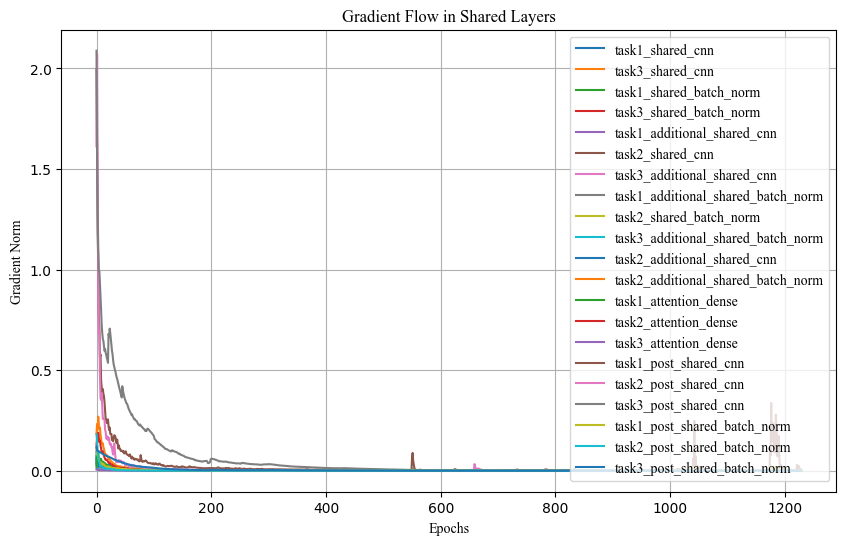

In [16]:
from tensorflow.keras.callbacks import Callback

class MultiTaskEarlyStopping(Callback):
    def __init__(self, patience=10):
        super(MultiTaskEarlyStopping, self).__init__()
        self.patience = patience
        self.best_losses = [float('inf'), float('inf'), float('inf')]  
        self.wait = 0  
 
    def on_epoch_end(self, epoch, logs=None):
        current_losses = [
            logs.get('output_task1_loss'),
            logs.get('output_task2_loss'),
            logs.get('output_task3_loss')
        ]
 
        if any(current < best for current, best in zip(current_losses, self.best_losses)):
            self.best_losses = current_losses
            self.wait = 0
        else:
            self.wait += 1
 
        if self.wait >= self.patience:
            print(f"Stopping training at epoch {epoch + 1}")
            self.model.stop_training = True
 
multi_task_early_stopping = MultiTaskEarlyStopping(patience=10)

class GradientTrackingCallback(tf.keras.callbacks.Callback):
    def __init__(self, model, X_train, Y_train):
        super().__init__()
        self.model = model
        self.X_train = X_train
        self.Y_train = Y_train
        self.gradient_history = {}

    def on_train_begin(self, logs=None):  
        self.gradient_history = {}

    def on_epoch_end(self, epoch, logs=None):
        with tf.device('/cpu:0'):  
            with tf.GradientTape() as tape:
                tape.watch(self.model.trainable_variables)
                predictions = self.model(self.X_train, training=True)
                losses = [
                    tf.keras.losses.CategoricalCrossentropy()(self.Y_train[i], predictions[i])
                    for i in range(3)
                ]
                total_loss = tf.reduce_sum(losses)

            gradients = tape.gradient(total_loss, self.model.trainable_variables)

            for var, grad in zip(self.model.trainable_variables, gradients):
                layer_name = var.name.split('/')[0].lower()
                if "shared" in layer_name or "attention" in layer_name:
                    if layer_name not in self.gradient_history:
                        self.gradient_history[layer_name] = {}  
                    if grad is not None:
                        self.gradient_history[layer_name][epoch] = tf.norm(grad).numpy() 

        del tape, predictions, losses, total_loss
        tf.keras.backend.clear_session()

gradient_tracking_callback = GradientTrackingCallback(
    model,
    [X_train_prim, X_train_actions, X_train_act],
    [y_train_prim, y_train_actions, y_train_act]
)

history = model.fit(
    [X_train_prim, X_train_actions, X_train_act],
    [y_train_prim, y_train_actions, y_train_act],
    epochs=3000,
    batch_size=64,
    shuffle=True,
    callbacks=[multi_task_early_stopping, 
               KalmanUpdateCallback(w1, w2, w3, a1, a2, error_estimate_w1, error_estimate_w2, error_estimate_w3, error_estimate_a1, error_estimate_a2),
              gradient_tracking_callback]
)

import pandas as pd

gradient_data = gradient_tracking_callback.gradient_history  

csv_filename = "gradient_data_ASSL.csv"
gradient_list = []

for layer, gradients in gradient_data.items():
    for epoch, value in gradients.items():
        gradient_list.append({"Epoch": epoch, "Layer": layer, "Gradient Norm": value})

gradient_df = pd.DataFrame(gradient_list)

gradient_df.to_csv(csv_filename, index=False)

print(f"Gradient data saved to {csv_filename}")

plt.figure(figsize=(10, 6))
for layer, gradients in gradient_data.items():
    epochs = list(gradients.keys())  
    values = list(gradients.values())
    plt.plot(epochs, values, label=f"{layer}")

plt.xlabel("Epochs", fontname="Times New Roman")
plt.ylabel("Gradient Norm", fontname="Times New Roman")
plt.title("Gradient Flow in Shared Layers", fontname="Times New Roman")
plt.legend(prop={'family': 'Times New Roman'})  
plt.grid()

# Save PNG
plt.savefig("gradient_flowASSL.png", dpi=300)
plt.show()

In [ ]:
task1_model = Model(inputs=model.input[0], outputs=model.output[0])
predictions_task1 = task1_model.predict(X_test_prim)

In [ ]:
import numpy as np

if isinstance(X_test_actions, list):
    X_test_actions = np.array(X_test_actions)
if isinstance(y_test_actions, list):
    y_test_actions = np.array(y_test_actions)

print(f"Task 2 Train: {X_train_actions.shape}, {y_train_actions.shape}")
print(f"Task 2 Test: {X_test_actions.shape}, {y_test_actions.shape}")

In [ ]:
X_test_actions = tf.convert_to_tensor(X_test_actions, dtype=tf.float32)

task2_model = Model(inputs=model.input[1], outputs=model.output[1])
predictions_task2 = task2_model.predict(X_test_actions)

In [ ]:
task3_model = Model(inputs=model.input[2], outputs=model.output[2])
predictions_task3 = task3_model.predict(X_test_act)

In [ ]:
from sklearn.metrics import mean_squared_error, accuracy_score

# Task 1 - Classification accuracy
accuracy_task1 = accuracy_score(np.argmax(y_test_prim, axis=1), np.argmax(predictions_task1, axis=1))

# Task 2 - Classification accuracy
accuracy_task2 = accuracy_score(np.argmax(y_test_actions, axis=1), np.argmax(predictions_task2, axis=1))

# Task 3 - Classification accuracy
accuracy_task3 = accuracy_score(np.argmax(y_test_act, axis=1), np.argmax(predictions_task3, axis=1))

print(f"Task 1 - Accuracy: {accuracy_task1}")
print(f"Task 2 - Accuracy: {accuracy_task2}")
print(f"Task 3 - Accuracy: {accuracy_task3}")

# Weighted average accuracy
n_task1 = len(y_test_prim)
n_task2 = len(y_test_actions)
n_task3 = len(y_test_act)

total_samples = n_task1 + n_task2 + n_task3
weighted_accuracy = (accuracy_task1 * n_task1 + accuracy_task2 * n_task2 + accuracy_task3 * n_task3) / total_samples

print(f"Weighted Accuracy: {weighted_accuracy}")

In [ ]:
from tensorflow.keras.losses import categorical_crossentropy

# Task 1 - Loss
loss_task1 = np.mean(categorical_crossentropy(data_y_T1_test, predictions_task1).numpy())
print(f"Task 1 - Loss: {loss_task1:.4f}")

# Task 2 - Loss
loss_task2 = np.mean(categorical_crossentropy(data_y_T2_test, predictions_task2).numpy())
print(f"Task 2 - Loss: {loss_task2:.4f}")

# Task 3 - Loss
loss_task3 = np.mean(categorical_crossentropy(data_y_T3_test, predictions_task3).numpy())
print(f"Task 3 - Loss: {loss_task3:.4f}")